# Optimal Transport in linear Independent Component Analysis
### Simulated Experiment: 4D IC extraction

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.stats
from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. Simulation Setup (4 Dimensions)
# ==========================================
n_samples = 5000
np.random.seed(42)
torch.manual_seed(42)

# Source 1: Laplace (Super-Gaussian, sharp peak)
s1 = np.random.laplace(0, 1, n_samples)

# Source 2: Uniform (Sub-Gaussian, flat)
s2 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n_samples)

# Source 3: Student-t (Heavy tails, df=3)
s3 = np.random.standard_t(df=3, size=n_samples)

# Source 4: Beta(0.5, 0.5) (Arcsine distribution, U-shaped, Sub-Gaussian)
# Centered and normalized
s4 = np.random.beta(0.5, 0.5, size=n_samples)
s4 = (s4 - np.mean(s4)) / np.std(s4)

In [3]:
# Stack and Mix
S_true = np.stack([s1, s2, s3, s4])
n_sources = 4
source_names = ['Laplace', 'Uniform', 'Student-t', 'Beta(0.5, 0.5)']

# Random 4x4 Mixing Matrix
A_true = np.random.randn(n_sources, n_sources)
# Ensure it's well-conditioned (invertible)
while np.linalg.cond(A_true) > 50:
    A_true = np.random.randn(n_sources, n_sources)

X_mixed = A_true @ S_true
X_torch = torch.tensor(X_mixed, dtype=torch.float32)

print(f"Simulated {n_sources} sources with {n_samples} samples.")

Simulated 4 sources with 5000 samples.


In [4]:
# ==========================================
# 2. Wasserstein ICA Extraction
# ==========================================
ica = WassersteinICA(X_torch)
ica.whiten()

extracted_weights = []
extracted_signals = []

print("\n--- Starting Sequential Extraction ---")
for i in range(n_sources):
    # Enforce orthogonality to all previously found components
    prev = torch.stack(extracted_weights) if extracted_weights else None
    
    # Run optimization (Autograd mode recommended)
    w, dist = ica.optimize_wasserstein2(
        prev_components=prev, 
        continuous=True, 
        max_iter=500,  # Increased iterations for 4D
        lr=0.05
    )
    
    extracted_weights.append(w)
    
    # Project data to get the signal
    y = torch.mv(ica.X_white.t(), w).cpu().numpy()
    extracted_signals.append(y)
    print(f"Component {i+1} extracted. W2 Distance: {dist:.4f}")

Y_est = np.stack(extracted_signals)
W_ica = torch.stack(extracted_weights).cpu().numpy()


--- Starting Sequential Extraction ---
Component 1 extracted. W2 Distance: 0.1033
Component 2 extracted. W2 Distance: 0.1166
Component 3 extracted. W2 Distance: 0.0431
Component 4 extracted. W2 Distance: 0.0376


In [5]:
# ==========================================
# 3. Mixing Matrix Matching
# ==========================================
# We want to compare the Total Mixing Matrix G = W_ica * W_white * A_true
# Ideally, G should be a Permutation Matrix (with scaling/signs).

# Reconstruct Whitening Matrix (W_white) from the class data
# (Since X_white = W_white * (X - mu))
X_centered = ica.X - torch.mean(ica.X, dim=1, keepdim=True)
cov = torch.matmul(X_centered, X_centered.t()) / (n_samples - 1)
D, E = torch.linalg.eigh(cov)
D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D + 1e-5))
W_white = torch.matmul(D_inv_sqrt, E.T).cpu().numpy()

# Compute Global Matrix G
# G[i, j] tells us how much of Original Source j is in Extracted Component i
G = W_ica @ W_white @ A_true

print("\n--- Global Mixing Matrix G (Rows=Extracted, Cols=Original) ---")
print(np.round(G, 2))

# Match sources based on maximum absolute contribution
matches = []
# For each Extracted Component (Row), find the Original Source (Col) with max weight
for i in range(n_sources):
    row_abs = np.abs(G[i])
    best_match_idx = np.argmax(row_abs)
    correlation = G[i, best_match_idx]
    
    matches.append({
        "extracted_idx": i,
        "original_idx": best_match_idx,
        "original_name": source_names[best_match_idx],
        "sign": np.sign(correlation) # Detect if signal is flipped
    })

print("\n--- Matches Found ---")
for m in matches:
    print(f"Extracted IC {m['extracted_idx']+1} matches {m['original_name']} (Sign: {m['sign']})")


--- Global Mixing Matrix G (Rows=Extracted, Cols=Original) ---
[[ 0.   -0.    0.    1.  ]
 [-0.02  0.01 -0.61 -0.02]
 [ 0.    1.01  0.01  0.  ]
 [ 0.71  0.   -0.01 -0.  ]]

--- Matches Found ---
Extracted IC 1 matches Beta(0.5, 0.5) (Sign: 1.0)
Extracted IC 2 matches Student-t (Sign: -1.0)
Extracted IC 3 matches Uniform (Sign: 1.0)
Extracted IC 4 matches Laplace (Sign: 1.0)


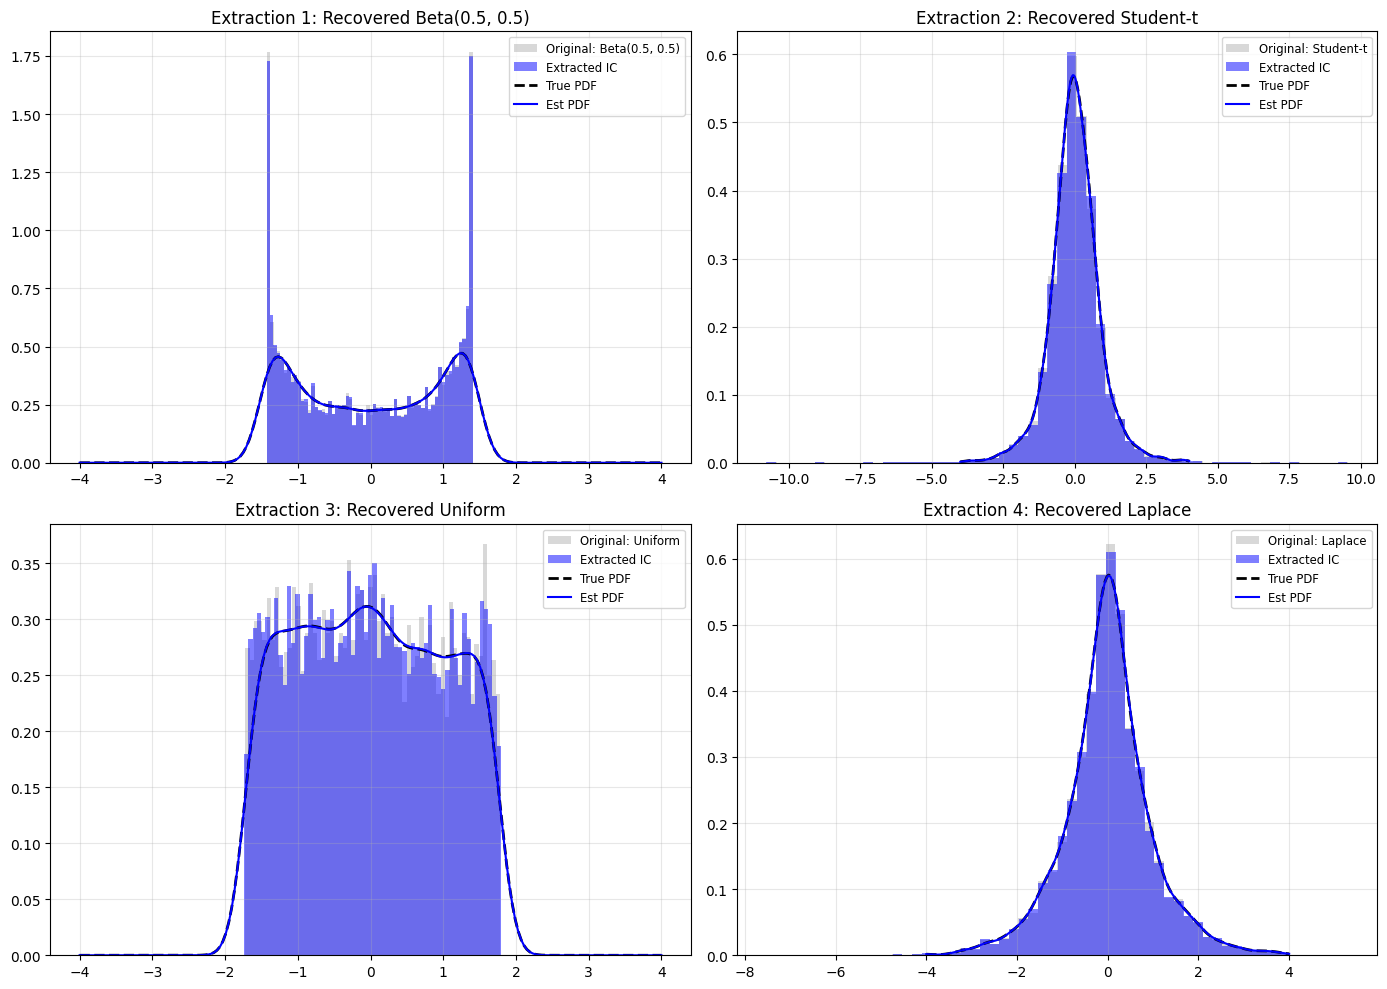

In [6]:
# ==========================================
# 4. Visualization
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
x_grid = np.linspace(-4, 4, 200)

for m in matches:
    i = m['extracted_idx']
    j = m['original_idx']
    sign = m['sign']
    
    # Get data
    orig = S_true[j]
    est = Y_est[i] * sign # Fix sign ambiguity
    
    # Normalize for clean PDF plotting
    orig = (orig - np.mean(orig)) / np.std(orig)
    est = (est - np.mean(est)) / np.std(est)
    
    ax = axes[i]
    
    # Histograms
    ax.hist(orig, bins=60, density=True, alpha=0.3, color='gray', label=f'Original: {source_names[j]}')
    ax.hist(est, bins=60, density=True, alpha=0.5, color='blue', label='Extracted IC')
    
    # KDE Lines (Smoothed PDF)
    try:
        kde_orig = scipy.stats.gaussian_kde(orig)
        kde_est = scipy.stats.gaussian_kde(est)
        ax.plot(x_grid, kde_orig(x_grid), 'k--', lw=2, label='True PDF')
        ax.plot(x_grid, kde_est(x_grid), 'b-', lw=1.5, label='Est PDF')
    except:
        print(f"KDE failed for {source_names[j]}")

    ax.set_title(f"Extraction {i+1}: Recovered {source_names[j]}")
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison: Wasserstein versus FAST ICA using Amari Similarity measure

- P = U.M, where U is unmixing and M is mixing matrix and P should ideally have only one non zero entry per row

**The Formula**
$$
E_{Amari} = \frac{1}{2n(n-1)} \left[ \sum_{i=1}^{n} \left( \frac{\sum_{j=1}^{n} |g_{ij}|}{\max_j |g_{ij}|} - 1 \right) + \sum_{j=1}^{n} \left( \frac{\sum_{i=1}^{n} |g_{ij}|}{\max_i |g_{ij}|} - 1 \right) \right]
$$

**Interpretation**
* **0.0**: Perfect Separation (The matrices match exactly up to permutation/scale).
* **< 0.2**: Good/Acceptable Separation.
* **> 0.5**: Poor Separation (Failed to unmix).

In [7]:
# ==========================================
# 1. Helper: Amari Error Function
# ==========================================
def amari_error(W_est, A_true):
    """
    Computes the Amari Performance Index.
    Measures how close P = W_est @ A_true is to a Permutation Matrix.
    0 = Perfect recovery.
    """
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    
    # Sum over rows
    row_sum = np.sum(P, axis=1)
    row_max = np.max(P, axis=1)
    # Normalize rows by their max element and subtract 1
    term1 = np.sum((row_sum / row_max) - 1)
    
    # Sum over cols
    col_sum = np.sum(P, axis=0)
    col_max = np.max(P, axis=0)
    # Normalize cols by their max element and subtract 1
    term2 = np.sum((col_sum / col_max) - 1)
    
    return (term1 + term2) / (2 * n * (n - 1))

In [8]:
# ==========================================
# 3. Method 1: Wasserstein ICA
# ==========================================
print("\n--- Running Wasserstein ICA ---")
ica_w = WassersteinICA(X_torch)
ica_w.whiten()

# Extract W_ica (The Unmixing Matrix)
# Note: In your class, W_est is built row by row
extracted_weights = []
for i in range(n_sources):
    prev = torch.stack(extracted_weights) if extracted_weights else None
    w, _ = ica_w.optimize_wasserstein2(prev_components=prev, continuous=True, max_iter=300, lr=0.1)
    extracted_weights.append(w)

W_wasserstein_sphere = torch.stack(extracted_weights).cpu().numpy()

# RECONSTRUCT TOTAL UNMIXING MATRIX
# Your class separates whitening from extraction.
# Total W = W_sphere @ W_whiten
# We need W_whiten explicitly
X_centered = ica_w.X - torch.mean(ica_w.X, dim=1, keepdim=True)
cov = torch.matmul(X_centered, X_centered.t()) / (n_samples - 1)
D, E = torch.linalg.eigh(cov)
D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D + 1e-5))
W_white = torch.matmul(D_inv_sqrt, E.T).cpu().numpy()

W_total_wasserstein = W_wasserstein_sphere @ W_white

# Calculate Score
score_wasserstein = amari_error(W_total_wasserstein, A_true)
print(f"Wasserstein ICA Amari Error: {score_wasserstein:.5f}")


--- Running Wasserstein ICA ---
Wasserstein ICA Amari Error: 0.01156


In [12]:
from sklearn.decomposition import FastICA


# ==========================================
# 4. Method 2: FastICA (sklearn)
# ==========================================
print("\n--- Running FastICA (sklearn) ---")
# FastICA expects shape (n_samples, n_features)
X_sklearn = X_mixed.T 

# Algorithm 1: Parallel FastICA with logcosh (approx Negentropy)
fastica = FastICA(n_components=n_sources, algorithm='parallel', fun='logcosh', random_state=42)
S_est_fast = fastica.fit_transform(X_sklearn)
W_total_fastica = fastica.components_ #@ fastica.whitening_ # Total unmixing matrix

score_fastica = amari_error(W_total_fastica, A_true)
print(f"FastICA (logcosh) Amari Error: {score_fastica:.5f}")


--- Running FastICA (sklearn) ---
FastICA (logcosh) Amari Error: 0.01016


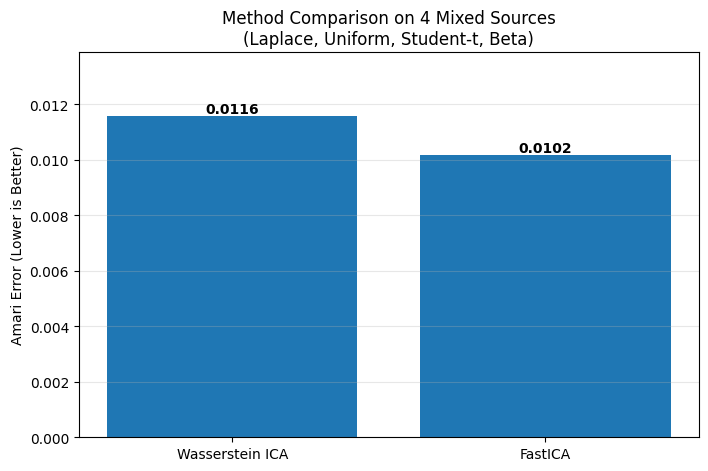


NOTE: FastICA performed better. This is common for simple sources.
Wasserstein ICA typically shines when FastICA fails (e.g., highly heavy tails or outliers).


In [13]:
# ==========================================
# 5. Visualization of Performance
# ==========================================
methods = ['Wasserstein ICA', 'FastICA']
scores = [score_wasserstein, score_fastica]

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, scores)

plt.ylabel('Amari Error (Lower is Better)')
plt.title(f'Method Comparison on {n_sources} Mixed Sources\n(Laplace, Uniform, Student-t, Beta)')
plt.ylim(0, max(scores)*1.2)
plt.grid(axis='y', alpha=0.3)

# Add text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", va='bottom', ha='center', fontweight='bold')

plt.show()

# Interpretation
if score_wasserstein < score_fastica:
    print("\nSUCCESS: Wasserstein ICA outperformed FastICA on this dataset.")
else:
    print("\nNOTE: FastICA performed better. This is common for simple sources.")
    print("Wasserstein ICA typically shines when FastICA fails (e.g., highly heavy tails or outliers).")